# 2. Baselines

In [ ]:
from src.new_models_module.shallow.xgb import SpatioTemporalXGBModel
from src.new_models_module.base.persistencemodel import PersistenceModel

## Load Data

In [ ]:
from src.dataloading.epidataloader import EpiDataLoader
from src.dataloading.gnndataloader import GNNDataLoader

from src.utils import get_data_env

disease_name    = 'influenza'
nuts_level      = 'nuts3'
min_date        ='2006-05-15'
max_date        = '2020-06-01'
split_trainval  = '2018-06-01'
split_valtest   = '2019-06-01'
split_berlin    = False


horizon_size    = 1
horizon_leadtime= 3
sequence_length = 1
lags            = 1

epidata_loader_basis = EpiDataLoader(disease_name, get_data_env(), nuts_level=nuts_level, min_date=min_date,max_date=max_date, include_population=False, horizon_size = horizon_size, horizon_leadtime = horizon_leadtime, sequence_length=sequence_length, split_berlin=split_berlin)
epidata_loader_basis.add_time_features()
epidata_loader_basis.log_transform_target()
epidata_loader_basis.set_splits(split_trainval, split_valtest)
epidata_loader_basis.normalize()
epidata_loader_basis.add_lagged_features(lags = lags)
epidata_loader_basis.finalize()

Dataloader temporal windowing: extending data collection from 2006-05-15 to 2006-04-17 (+4 weeks)
berlin districts removed


EpiDataLoader(disease=influenza, nuts_level=nuts3, min_date=2006-04-17, max_date=2020-06-01, horizon_size=1, horizon_leadtime=3, sequence_length=1)

## Persistence Model

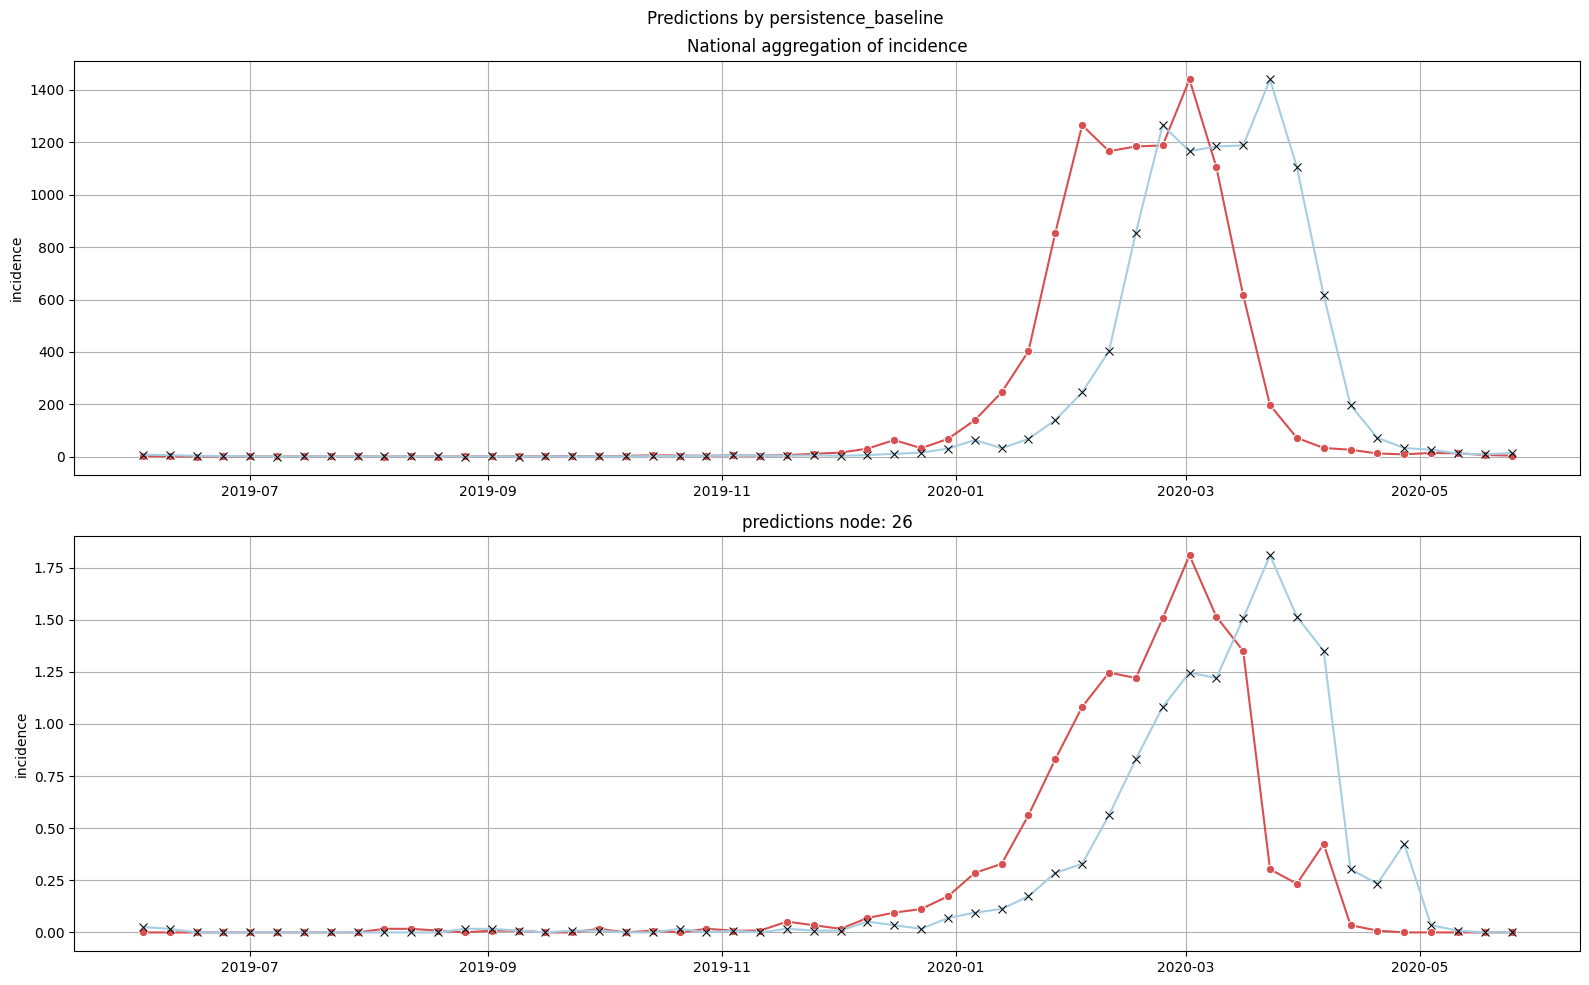

In [ ]:
persistence = PersistenceModel(epidata_loader_basis, name = 'persistence_baseline')
persistence.forecast('test')
persistence.show_forecasts('test',26);

## XGBoost models

Dataloader temporal windowing: extending data collection from 2006-05-15 to 2006-04-17 (+4 weeks)
berlin districts removed
Dataloader temporal windowing: extending data collection from 2006-05-15 to 2006-04-17 (+4 weeks)
berlin districts removed
Dataloader temporal windowing: extending data collection from 2006-05-15 to 2006-04-17 (+4 weeks)
berlin districts removed
Dataloader temporal windowing: extending data collection from 2006-05-15 to 2006-04-17 (+4 weeks)
berlin districts removed
Dataloader temporal windowing: extending data collection from 2006-05-15 to 2006-04-17 (+4 weeks)
berlin districts removed
Dataloader temporal windowing: extending data collection from 2006-05-15 to 2006-04-17 (+4 weeks)
berlin districts removed
Dataloader temporal windowing: extending data collection from 2006-05-15 to 2006-04-17 (+4 weeks)
berlin districts removed
⚠️ No neighbors found — skipping aggregation.
⚠️ No neighbors found — skipping aggregation.
⚠️ No neighbors found — skipping aggregation.
✓

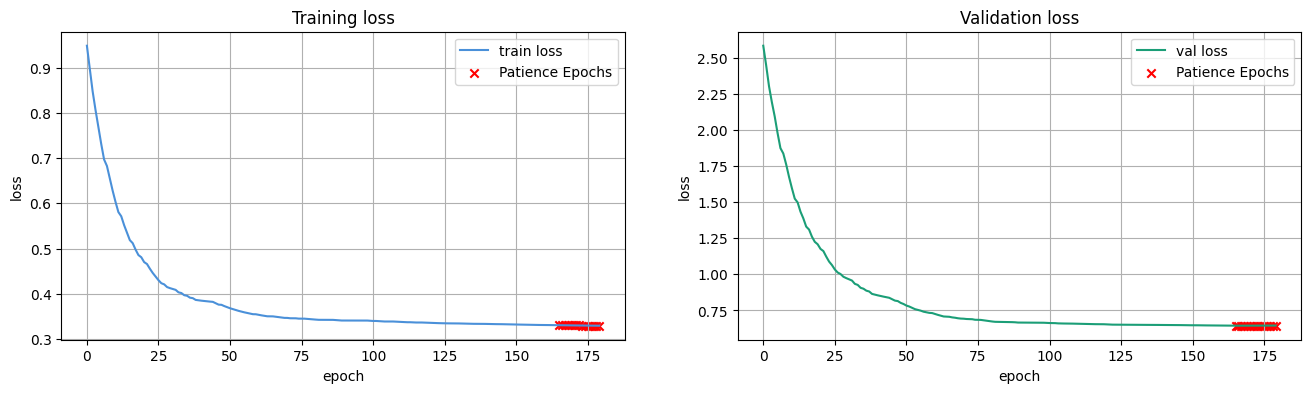

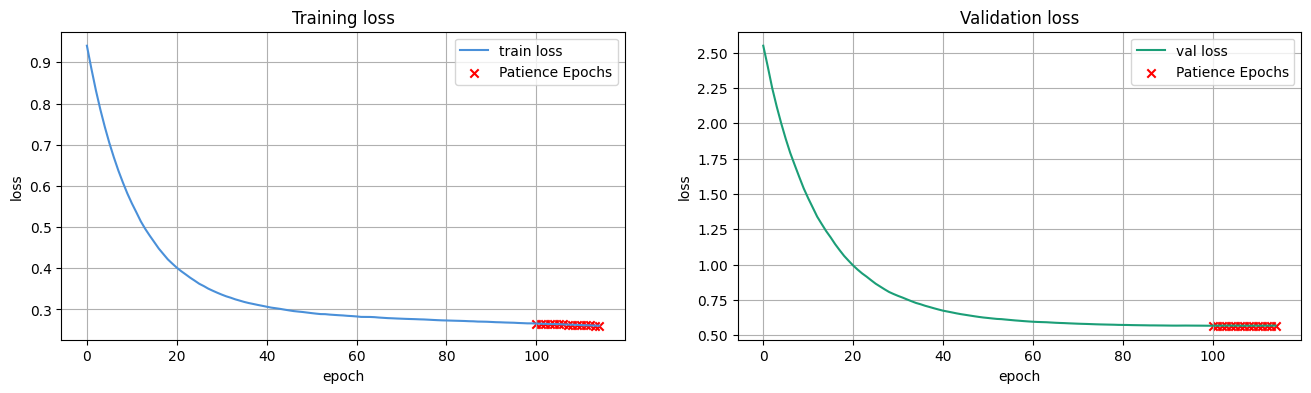

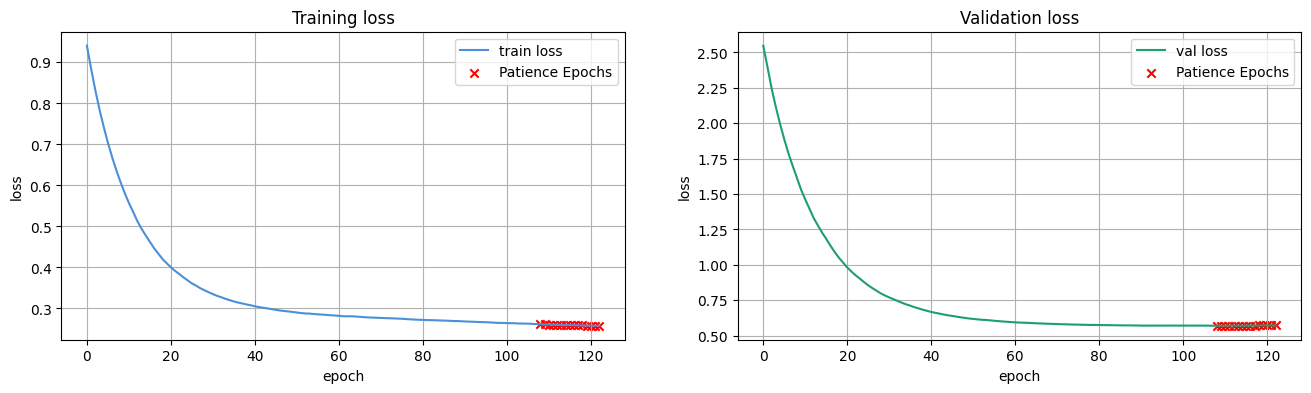

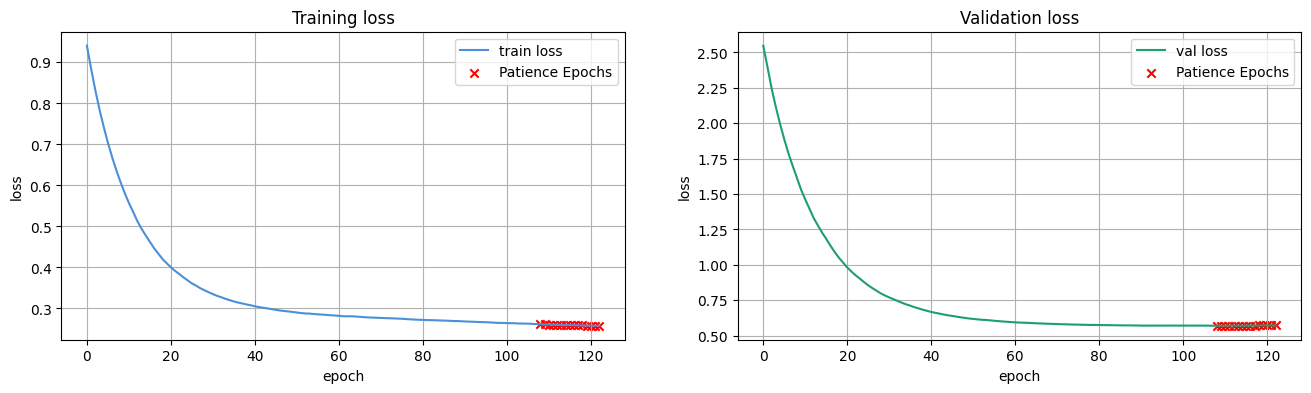

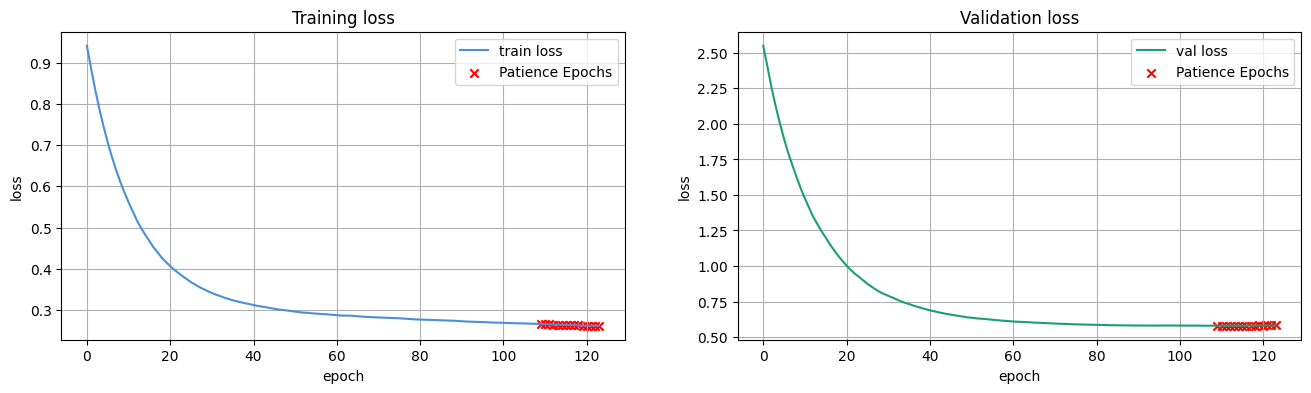

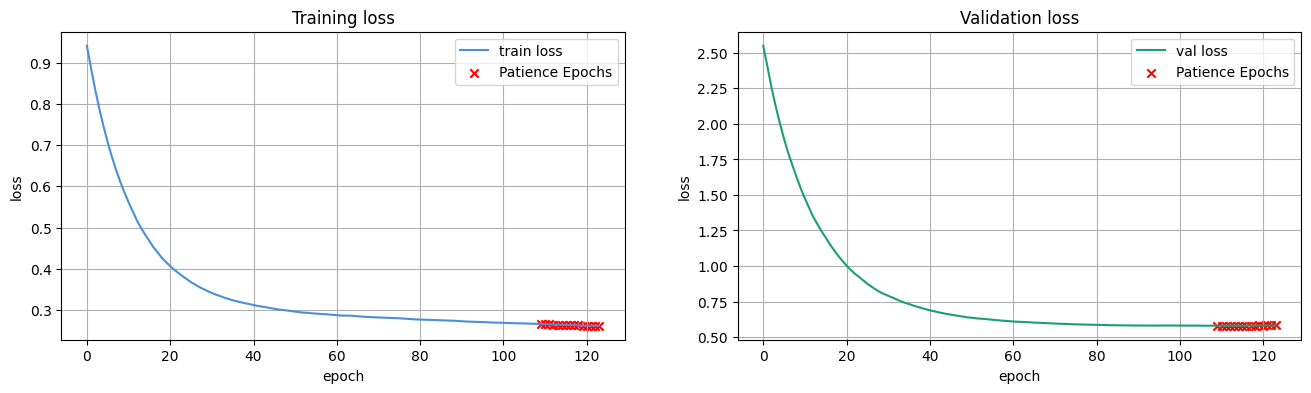

In [ ]:
n_epochs=250
xgboost_loader_basis = GNNDataLoader(disease_name, get_data_env(), nuts_level=nuts_level, min_date=min_date,max_date=max_date, include_population=False, horizon_size = horizon_size, horizon_leadtime = horizon_leadtime, sequence_length=sequence_length, split_berlin=split_berlin)
xgboost_loader_basis.add_time_features()
xgboost_loader_basis.log_transform_target()
xgboost_loader_basis.set_splits(split_trainval, split_valtest)
xgboost_loader_basis.normalize()
xgboost_loader_basis.add_lagged_features(lags = lags)
xgboost_loader_basis.finalize()

xgboost_loader_idgraph= xgboost_loader_basis.copy().retrieve_graph('identity_selfmax').construct_dataloaders()
xgboost_loader_bngraph= xgboost_loader_basis.copy().retrieve_graph('boolean_neighbors_selfmean').construct_dataloaders()
xgboost_loader_commuting1= xgboost_loader_basis.copy().retrieve_graph('commuter_t1000_selfmean_rowwise').construct_dataloaders()
xgboost_loader_commuting2= xgboost_loader_basis.copy().retrieve_graph('commuter_t2000_selfmean_rowwise').construct_dataloaders()

xgboost_idgraph = SpatioTemporalXGBModel(xgboost_loader_idgraph, name = 'xgboost - id graph')
xgboost_idgraph.set_global_hparams(lr = 0.05, n_epochs=n_epochs)
xgboost_idgraph.set_model_hparams(max_depth = 10, n_estimators=1000)
xgboost_idgraph.train(verbose = 0)
xgboost_idgraph.forecast('test')

xgboost_bngraph = SpatioTemporalXGBModel(xgboost_loader_bngraph, name = 'xgboost - bn graph')
xgboost_bngraph.set_global_hparams(lr = 0.05, n_epochs=n_epochs)
xgboost_bngraph.set_model_hparams(max_depth = 10, n_estimators=1000)
xgboost_bngraph.train(verbose = 0)
xgboost_bngraph.forecast('test')

xgboost_cmgraph1 = SpatioTemporalXGBModel(xgboost_loader_commuting1, name = 'xgboost - static commuter graph 1')
xgboost_cmgraph1.set_global_hparams(lr = 0.05, n_epochs=n_epochs)
xgboost_cmgraph1.set_model_hparams(max_depth = 10, n_estimators=1000)
xgboost_cmgraph1.train(verbose = 0)
xgboost_cmgraph1.forecast('test')

xgboost_cmgraph2 = SpatioTemporalXGBModel(xgboost_loader_commuting2, name = 'xgboost - static commuter graph 2')
xgboost_cmgraph2.set_global_hparams(lr = 0.05, n_epochs=n_epochs)
xgboost_cmgraph2.set_model_hparams(max_depth = 10, n_estimators=1000)
xgboost_cmgraph2.train(verbose = 0)
xgboost_cmgraph2.forecast('test')



## Evaluation

In [ ]:
from src.metrics.evaluator import Evaluator

In [ ]:
evaluation = Evaluator(models = [persistence,xgboost_idgraph,xgboost_bngraph,xgboost_cmgraph1,xgboost_cmgraph2], horizon_leadtime= horizon_leadtime)
evaluation.add_evaluation()
evaluation.plot_metric('rmse',      plot_type='violin')
evaluation.plot_metric('ccc',       plot_type='box')
evaluation.plot_metric('corr',      plot_type='box')
evaluation.plot_metric('lag_corr',  plot_type='violin')

KeyboardInterrupt: 